# **Tahap 0: Config**

In [102]:
%pip install -q ta

Note: you may need to restart the kernel to use updated packages.


In [103]:
import os
import random
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import joblib

import optuna
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Attention
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, accuracy_score
import gc

# Opsional: Kalo lu pake library 'ta' buat indikator teknikal yang ribet kayak MACD/RSI
# Kalo belum install, ketik: !pip install ta
import ta

In [104]:
# Maksa GPU (CuDNN) di Kaggle biar ga ngacak hitungan
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(42)

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [105]:
def kunci_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Fitur eksperimental TF buat ngunci semua operasi tensor
    tf.config.experimental.enable_op_determinism() 

kunci_seed(42)

# **TAHAP 1: Data Acquisition & Feature Engineering (Hulu)**

Ini fase di mana kita ngumpulin bahan baku dan meracik "bumbu".

* **Tarik Data:** Kita bikin satu fungsi *scraper* `yfinance` buat narik data harga (`Open, High, Low, Close, Volume`) selama 5 tahun ke belakang.
* **Feature Engineering (22 Indikator):** Model AI itu buta arah kalau cuma dikasih harga murni. Kita harus ngitung indikator teknikal. Kita masukin *Moving Average* (SMA/EMA) biar model tau tren, RSI & MACD biar model tau momentum, dan *Bollinger Bands* buat ngukur volatilitas.
* **Bikin Target (Label):** Ini yang paling krusial. Kita bikin satu kolom baru bernama `Target_Return_40d`. Rumusnya adalah membandingkan harga hari ini dengan harga 40 hari ke depan. Kolom inilah yang bakal jadi "Kunci Jawaban" pas model lagi belajar. Setelah dibikin, kita buang baris yang kosong (*drop NaN*).

In [106]:
daftar_saham = ['BRMS.JK', 'ANTM.JK', 'MDKA.JK', 'HRTA.JK', 'PSAB.JK']
lemari_dataset = []

In [107]:
def siapkan_data_hulu(ticker="BRMS.JK", horizon=40):
    print(f"[*] Sedang menyedot data 5 Tahun untuk {ticker}...")
    
    # 1. Tarik Data Mentah
    df = yf.download(ticker, period="5y", interval="1d", auto_adjust=True)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

    emas_dunia = yf.download("GC=F", period="5y", interval="1d", auto_adjust=True)['Close']
    fed_rate = yf.download("^IRX", period="5y", interval="1d", auto_adjust=True)['Close']
    usd_idr = yf.download("IDR=X", period="5y", interval="1d", auto_adjust=True)['Close']

    df['Macro_Gold_World'] = emas_dunia
    df['Macro_US_Rate'] = fed_rate
    df['Macro_USD_IDR'] = usd_idr

    # Karena bursa Indo dan US liburnya beda, pasti ada nilai NaN pas digabung. 
    # Kita isi pakai teknik Forward-Fill (harga kemarin dilanjutin ke hari ini)
    df.fillna(method='ffill', inplace=True)
    
    # 2. FEATURE ENGINEERING (Tugas Lu!)
    # Ini gue contohin 2 biji. Tugas lu tambahin indikator lain 
    # (misal SMA 50, EMA 12, RSI, atau MACD) biar fiturnya makin kaya.
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['Return_1d'] = df['Close'].pct_change()
    
    # 3. BIKIN TARGET (KUNCI JAWABAN BUAT AI)
    # Kita nyuruh pandas ngintip harga 40 hari ke depan, terus dihitung persentase return-nya
    df['Target_Return_40d'] = df['Close'].shift(-horizon)
    df['Target_Return_40d'] = (df['Target_Return_40d'].values - df['Close'].values) / df['Close'].values
    
    # 4. BERES-BERES
    # Gara-gara ada .rolling() dan .shift(), pasti banyak baris awal dan akhir yang jadi NaN. Kita buang!
    df = df.dropna()
    
    return df

for ticker in daftar_saham:
    print(f"\n{'='*50}")
    print(f"MEMPROSES SAHAM: {ticker}")
    print(f"{'='*50}")
        
    data_mentah = siapkan_data_hulu(ticker=ticker, horizon=40)
    lemari_dataset.append(data_mentah)

[*********************100%***********************]  1 of 1 completed


MEMPROSES SAHAM: BRMS.JK
[*] Sedang menyedot data 5 Tahun untuk BRMS.JK...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_102/22036971.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



MEMPROSES SAHAM: ANTM.JK
[*] Sedang menyedot data 5 Tahun untuk ANTM.JK...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_102/22036971.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_102/22036971.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
[*********************100%***********************]  1 of 1 completed



MEMPROSES SAHAM: HRTA.JK
[*] Sedang menyedot data 5 Tahun untuk HRTA.JK...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_102/22036971.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



MEMPROSES SAHAM: PSAB.JK
[*] Sedang menyedot data 5 Tahun untuk PSAB.JK...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_102/22036971.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [108]:
for ticker in lemari_dataset:
    print(f"\n{'='*50}")
    print(f"MEMPROSES SAHAM: {ticker.columns[0][1]}")
    print(f"{'='*50}")
        
    print(ticker.tail(), "\n")


MEMPROSES SAHAM: BRMS.JK
Price         Open    High     Low   Close     Volume Macro_Gold_World  \
Ticker     BRMS.JK BRMS.JK BRMS.JK BRMS.JK    BRMS.JK                    
Date                                                                     
2026-05-18   755.0   755.0   685.0   720.0  304758200      4552.500000   
2026-05-19   725.0   755.0   640.0   670.0  347153700      4506.299805   
2026-05-20   660.0   680.0   600.0   660.0  314119800      4531.299805   
2026-05-21   680.0   680.0   565.0   565.0  762648000      4539.799805   
2026-05-22   540.0   640.0   500.0   630.0  666888600      4519.299805   

Price      Macro_US_Rate Macro_USD_IDR SMA_10  SMA_20 Return_1d  \
Ticker                                                            
Date                                                              
2026-05-18         3.568  17586.000000  773.0  807.75 -0.064935   
2026-05-19         3.575  17701.000000  761.5  796.00 -0.069444   
2026-05-20         3.557  17777.000000  745.5 

In [109]:
for ticker in lemari_dataset:
    print(f"\n{'='*50}")
    print(f"MEMPROSES SAHAM: {ticker.columns[0][1]}")
    print(f"{'='*50}")
    
    print(ticker.isnull().sum(), "\n\n")


MEMPROSES SAHAM: BRMS.JK
Price              Ticker 
Open               BRMS.JK    0
High               BRMS.JK    0
Low                BRMS.JK    0
Close              BRMS.JK    0
Volume             BRMS.JK    0
Macro_Gold_World              0
Macro_US_Rate                 0
Macro_USD_IDR                 0
SMA_10                        0
SMA_20                        0
Return_1d                     0
Target_Return_40d             0
dtype: int64 



MEMPROSES SAHAM: ANTM.JK
Price              Ticker 
Open               ANTM.JK    0
High               ANTM.JK    0
Low                ANTM.JK    0
Close              ANTM.JK    0
Volume             ANTM.JK    0
Macro_Gold_World              0
Macro_US_Rate                 0
Macro_USD_IDR                 0
SMA_10                        0
SMA_20                        0
Return_1d                     0
Target_Return_40d             0
dtype: int64 



MEMPROSES SAHAM: MDKA.JK
Price              Ticker 
Open               MDKA.JK    0
High     

In [110]:
for ticker in lemari_dataset:
    print(f"\n{'='*50}")
    print(f"MEMPROSES SAHAM: {ticker.columns[0][1]}")
    print(f"{'='*50}")
    
    print(ticker.describe().T, "\n\n")


MEMPROSES SAHAM: BRMS.JK
                            count          mean           std           min  \
Price             Ticker                                                      
Open              BRMS.JK  1183.0  3.167700e+02  2.798113e+02     79.823868   
High              BRMS.JK  1183.0  3.260150e+02  2.887653e+02     80.752052   
Low               BRMS.JK  1183.0  3.068616e+02  2.686767e+02     78.895683   
Close             BRMS.JK  1183.0  3.156487e+02  2.780302e+02     79.823868   
Volume            BRMS.JK  1183.0  5.378044e+08  6.022193e+08      0.000000   
Macro_Gold_World           1183.0  2.508414e+03  9.397316e+02   1623.300049   
Macro_US_Rate              1183.0  3.524743e+00  1.804829e+00      0.020000   
Macro_USD_IDR              1183.0  1.555842e+04  8.516751e+02  14067.000000   
SMA_10                     1183.0  3.134184e+02  2.763839e+02     81.865874   
SMA_20                     1183.0  3.105525e+02  2.740571e+02     83.907880   
Return_1d                 

---

# **TAHAP 2: Preprocessing & Anti-Leakage Splitting (Filter Keamanan)**

Di sinilah letak nyawa validasi sistem lu biar nggak dituduh *data leakage* pas sidang nanti.

* **Scaling:** Harga saham dari ribuan perak kita pres jadi angka desimal 0 sampai 1 pakai `MinMaxScaler`. Kenapa? Biar aktivasi *neural network* (GRU) lu nggak *error* gara-gara ngitung angka kegedean.
* **Train-Test Split & EMBARGO:** Kita potong data jadi dua. *Train Set* buat belajar, *Test Set* (60 hari terakhir) buat ujian. **TAPI**, di antara *Train* dan *Test* ini, kita kasih jeda waktu kosong (Embargo) selama 40 hari. Tujuannya murni biar *Train Set* sama sekali nggak punya kesempatan buat "ngintip" harga di kalender *Test Set*.
* **Sequence Generation:** Deret waktu yang panjang itu kita potong-potong jadi *window* kecil berukuran 60 hari (*lookback*). Ibaratnya, kita ngajarin AI: *"Nih baca pergerakan 60 hari terakhir, terus tebak return 40 hari ke depan."*

In [111]:

def siapkan_potongan_data(df, lookback=60, horizon=40, test_size=60):
    # 1. Update Fitur (Masukin 3 fitur makro yang baru lu tarik di Tahap 1)
    fitur = [
        'Open', 'High', 'Low', 'Close', 'Volume', 
        'Macro_Gold_World', 'Macro_US_Rate', 'Macro_USD_IDR', 
        'SMA_10', 'SMA_20', 'Return_1d'
    ]
    
    # 2. POTONG DATA DENGAN EMBARGO (ZONA MATI 40 HARI)
    train_df = df.iloc[:-test_size - horizon]
    test_df = df.iloc[-test_size:]
    
    # 3. SCALING (Karantina ketat: Scaler cuma belajar dari Train Set!)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df[fitur])
    test_scaled = scaler.transform(test_df[fitur])
    
    train_target = train_df['Target_Return_40d'].values
    test_target = test_df['Target_Return_40d'].values
    
    # 4. BIKIN SEQUENCE MATRIKS 3D BUAT GRU
    def bikin_sequence(data_x, data_y):
        X_seq, y_seq = [], []
        for i in range(lookback, len(data_x)):
            X_seq.append(data_x[i-lookback : i])
            y_seq.append(data_y[i])
        return np.array(X_seq), np.array(y_seq)
    
    X_train, y_train = bikin_sequence(train_scaled, train_target)
    
    # Khusus Test Set: Tarik sisa 'lookback' dari ujung train set sebagai modal nebak hari pertama
    gabungan_test_x = np.vstack([train_scaled[-lookback:], test_scaled])
    gabungan_test_y = np.concatenate([train_target[-lookback:], test_target])
    
    X_test, y_test = bikin_sequence(gabungan_test_x, gabungan_test_y)
    
    print(f"[+] Ukuran X_train : {X_train.shape} -> (Jumlah Baris, Lookback, Jumlah Fitur)")
    print(f"[+] Ukuran y_train : {y_train.shape}")
    print(f"[+] Ukuran X_test  : {X_test.shape}")
    print(f"[+] Ukuran y_test  : {y_test.shape}")
    
    return X_train, y_train, X_test, y_test, scaler

In [112]:
lemari_dataset[0].columns[0][1]

'BRMS.JK'

In [113]:
lemari_split_dataset = {}

for data in lemari_dataset:
    print(f"\n{'='*50}")
    print(f"MEMPROSES SAHAM: {data.columns[0][1]}")
    print(f"{'='*50}")
    
    # 2. Panggil fungsi Tahap 2 (Potong Data Embargo)
    X_tr, y_tr, X_te, y_te, scaler_saham = siapkan_potongan_data(data, lookback=60, horizon=40, test_size=60)
    
    # 3. Simpan ke dalam lemari
    lemari_split_dataset[data.columns[0][1]] = {
        'X_train': X_tr,
        'y_train': y_tr,
        'X_test': X_te,
        'y_test': y_te,
        'scaler': scaler_saham
    }


MEMPROSES SAHAM: BRMS.JK
[+] Ukuran X_train : (1023, 60, 11) -> (Jumlah Baris, Lookback, Jumlah Fitur)
[+] Ukuran y_train : (1023,)
[+] Ukuran X_test  : (60, 60, 11)
[+] Ukuran y_test  : (60,)

MEMPROSES SAHAM: ANTM.JK
[+] Ukuran X_train : (1023, 60, 11) -> (Jumlah Baris, Lookback, Jumlah Fitur)
[+] Ukuran y_train : (1023,)
[+] Ukuran X_test  : (60, 60, 11)
[+] Ukuran y_test  : (60,)

MEMPROSES SAHAM: MDKA.JK
[+] Ukuran X_train : (1023, 60, 11) -> (Jumlah Baris, Lookback, Jumlah Fitur)
[+] Ukuran y_train : (1023,)
[+] Ukuran X_test  : (60, 60, 11)
[+] Ukuran y_test  : (60,)

MEMPROSES SAHAM: HRTA.JK
[+] Ukuran X_train : (1023, 60, 11) -> (Jumlah Baris, Lookback, Jumlah Fitur)
[+] Ukuran y_train : (1023,)
[+] Ukuran X_test  : (60, 60, 11)
[+] Ukuran y_test  : (60,)

MEMPROSES SAHAM: PSAB.JK
[+] Ukuran X_train : (1023, 60, 11) -> (Jumlah Baris, Lookback, Jumlah Fitur)
[+] Ukuran y_train : (1023,)
[+] Ukuran X_test  : (60, 60, 11)
[+] Ukuran y_test  : (60,)


---

# **TAHAP 3: True Stacked Modeling**

Ini dia menu utamanya. Kita nggak pake rata-rata biasa, tapi bener-bener saling tumpuk (*Stacking*).

* **Otak Kanan (Unidirectional GRU + Attention):** Jaringan saraf tiruan (GRU) ngebaca data 60 hari lu secara kronologis dari masa lalu ke masa kini (murni kausal, bebas *leakage*). Terus, lapisan *Attention* bakal ngasih *highlight* ke hari-hari tertentu yang pergerakannya ekstrem.
* **Proses Pemotongan Kepala (Bottleneck Extraction):** GRU tadi kita latih sebentar. Kalau udah pinter, *layer* terakhirnya (kepalanya) kita potong. Kita cuma ambil "vektor memori"-nya (sekitar 32 atau 64 angka desimal padat) yang isinya adalah sari pati pemahaman GRU terhadap pola pasar.
* **Otak Kiri (XGBoost Regressor):** Vektor memori dari GRU tadi kita lempar ke XGBoost. Algoritma pohon keputusan ini sifatnya kaku tapi sangat presisi secara matematis. Dia yang bakal nge- *compile* memori dari GRU jadi satu angka final: Prediksi persentase *Return*.

* **Optuna (Hyperparameter)**: Daripada lu nebak-nebak *learning rate* atau *kedalaman pohon* (max depth) XGBoost pakai insting dukun, kita suruh Optuna buat nge-*running* puluhan simulasi otomatis. Dia bakal nyari kombinasi paling mematikan buat nebak arah harga.
* **Huber Loss (reg:huber & tf.keras.losses.Huber)**: Ini pengganti `squarederror`. Pasar saham itu banyak *outlier* (lonjakan harga gila-gilaan gara-gara *hype*). Kalau pake *Squared Error*, AI lu bakal panik kalau ngeliat *outlier* dan akhirnya memilih nebak rata-rata (sindrom *Ultra-Conservative* yang bikin grafik lu datar kemaren). *Huber Loss* itu kebal sama *outlier*, jadi model lu bakal lebih "luwes" ngikutin tren yang ekstrem.

In [114]:
# Bikin lemari baru khusus buat nyimpen nilai rapot (Evaluasi)
lemari_evaluasi = {}

for ticker in daftar_saham:
    print(f"\n{'='*50}")
    print(f"SAHAM: {ticker}")
    print(f"{'='*50}")
    
    X_train = lemari_split_dataset[ticker]['X_train']
    y_train = lemari_split_dataset[ticker]['y_train']
    X_test  = lemari_split_dataset[ticker]['X_test']
    y_test  = lemari_split_dataset[ticker]['y_test']
    
    # ==================================================
    # A. OTAK KANAN (UNIDIRECTIONAL GRU + HUBER LOSS)
    # ==================================================
    input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
    gru_out = GRU(64, return_sequences=True)(input_layer) 
    attention_out = Attention()([gru_out, gru_out])   
    memory_vector = GRU(32, return_sequences=False)(attention_out)
    memory_vector = Dropout(0.2)(memory_vector)  
    
    temp_output = Dense(1)(memory_vector)

    gru_model = Model(inputs=input_layer, outputs=temp_output)    
    gru_model.compile(optimizer='adam', loss='mse')
    
    print("   [*] Pre-training GRU (Mencari pola kausal)...")
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    gru_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)
    
    print("   [*] Mengekstrak Memori GRU...")
    feature_extractor = Model(inputs=gru_model.input, outputs=gru_model.layers[-2].output)
    X_train_xgb = feature_extractor.predict(X_train, verbose=0)
    X_test_xgb = feature_extractor.predict(X_test, verbose=0)
    
    # ==================================================
    # B. OTAK KIRI (OPTUNA + XGBOOST)
    # ==================================================
    print("   [*] Eksekusi XGBoost...")
    
    def objective(trial):
        param = {
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_weight': trial.suggest_int('min_child_weight', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'subsample': 0.8,
            'objective': 'reg:squarederror',
            'random_state': 42,
            'n_jobs': -1
        }

        tscv = TimeSeriesSplit(n_splits=5)
        cv_scores = []
        for train_idx, val_idx in tscv.split(X_train_xgb):
            X_fold_train, X_fold_val = X_train_xgb[train_idx], X_train_xgb[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

            model = xgb.XGBRegressor(n_estimators=200, **param)
            model.fit(X_fold_train, y_fold_train,
                      eval_set=[(X_fold_val, y_fold_val)],
                      verbose=False)

            preds_val = model.predict(X_fold_val)
            cv_scores.append(mean_squared_error(y_fold_val, preds_val))

        return np.mean(cv_scores)
        
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50) # 30 simulasi per saham
    
    best_params = study.best_params

    xgb_final = xgb.XGBRegressor(n_estimators=200, **best_params)
    xgb_final.fit(X_train_xgb, y_train)
    
    # ==================================================
    # C. UJIAN AKHIR & SIMPAN PREDIKSI
    # ==================================================
    preds = xgb_final.predict(X_test_xgb)
    
    mse = mean_squared_error(y_test, preds) * 100
    actual_direction = np.where(y_test > 0, 1, -1)
    pred_direction = np.where(preds > 0, 1, -1)
    acc = accuracy_score(actual_direction, pred_direction) * 100
    
    print(f"   [+] Final mse             : {mse:.2f}%")
    print(f"   [+] Final Directional Acc  : {acc:.2f}%")
    
    # Simpen tebakan 'preds' buat divisualisasi di Tahap 4 nanti
    lemari_evaluasi[ticker] = {'preds': preds, 'mse': mse, 'Accuracy': acc}
    
    gru_model.save(f"models/gru_{ticker}.h5")
    
    # 2. Save Otak Kiri (XGBoost)
    xgb_final.save_model(f"models/xgb_{ticker}.json")
    
    # 3. Save Kacamata Scaler (PENTING BIAR GA ERROR PAS DEPLOY!)
    scaler_nya = lemari_split_dataset[ticker]['scaler']
    joblib.dump(scaler_nya, f"models/scaler_{ticker}.pkl")

    # Bersih-bersih RAM & VRAM GPU
    del gru_model, feature_extractor, xgb_final, study
    gc.collect()
    tf.keras.backend.clear_session()


SAHAM: BRMS.JK
   [*] Pre-training GRU (Mencari pola kausal)...


2026-05-22 11:51:35.771240: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


   [*] Mengekstrak Memori GRU...


2026-05-22 11:51:41.132858: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


   [*] Eksekusi XGBoost...


...

2026-05-22 11:57:12.841839: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


   [*] Mengekstrak Memori GRU...


2026-05-22 11:57:22.364713: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


   [*] Eksekusi XGBoost...


   [+] Final mse             : 0.16%
   [+] Final Directional Acc  : 100.00%



POST-PROCESSING & VISUALISASI

[*] Merender grafik analisis untuk BRMS.JK...


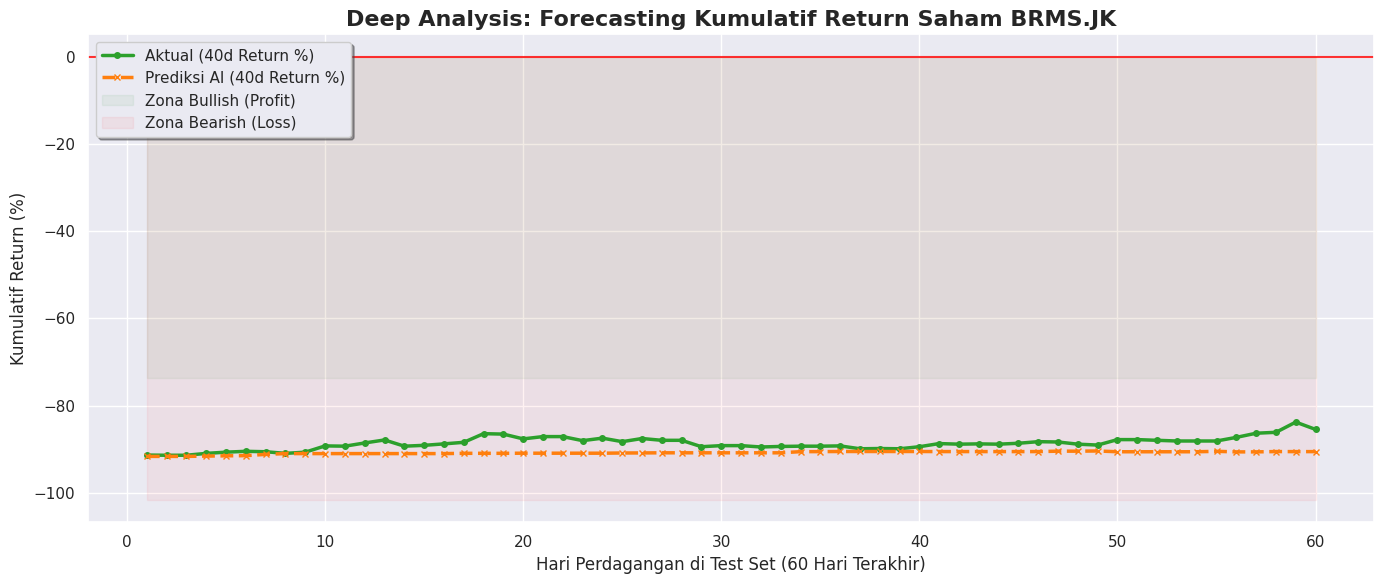


[*] Merender grafik analisis untuk ANTM.JK...


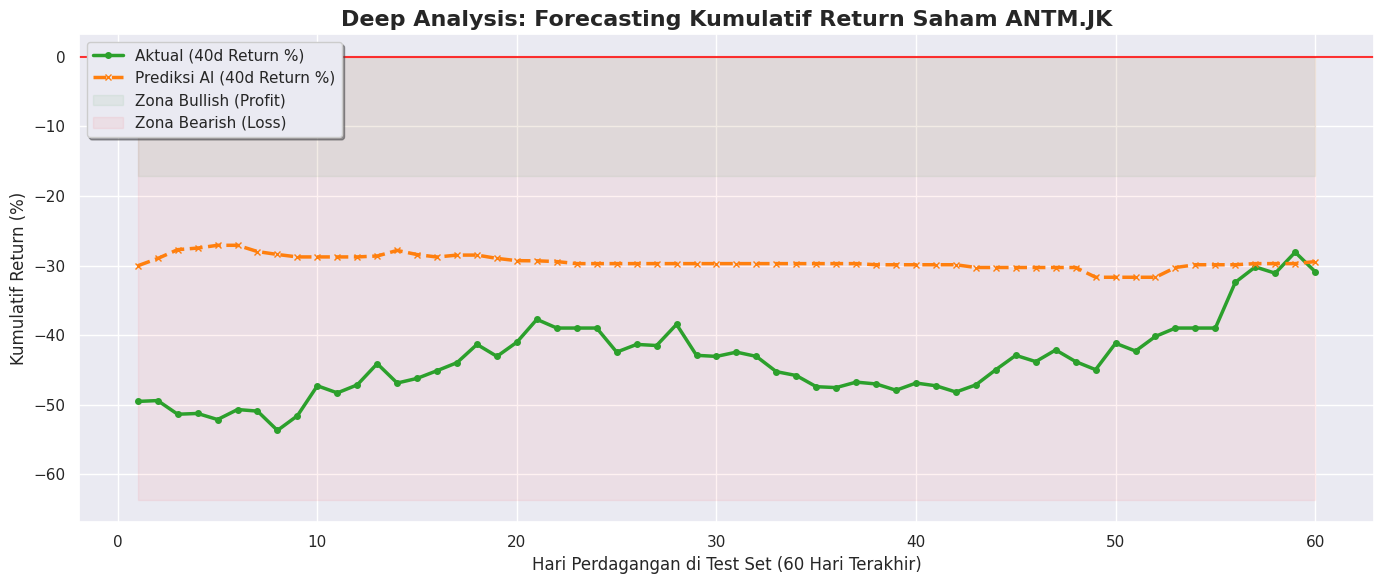


[*] Merender grafik analisis untuk MDKA.JK...


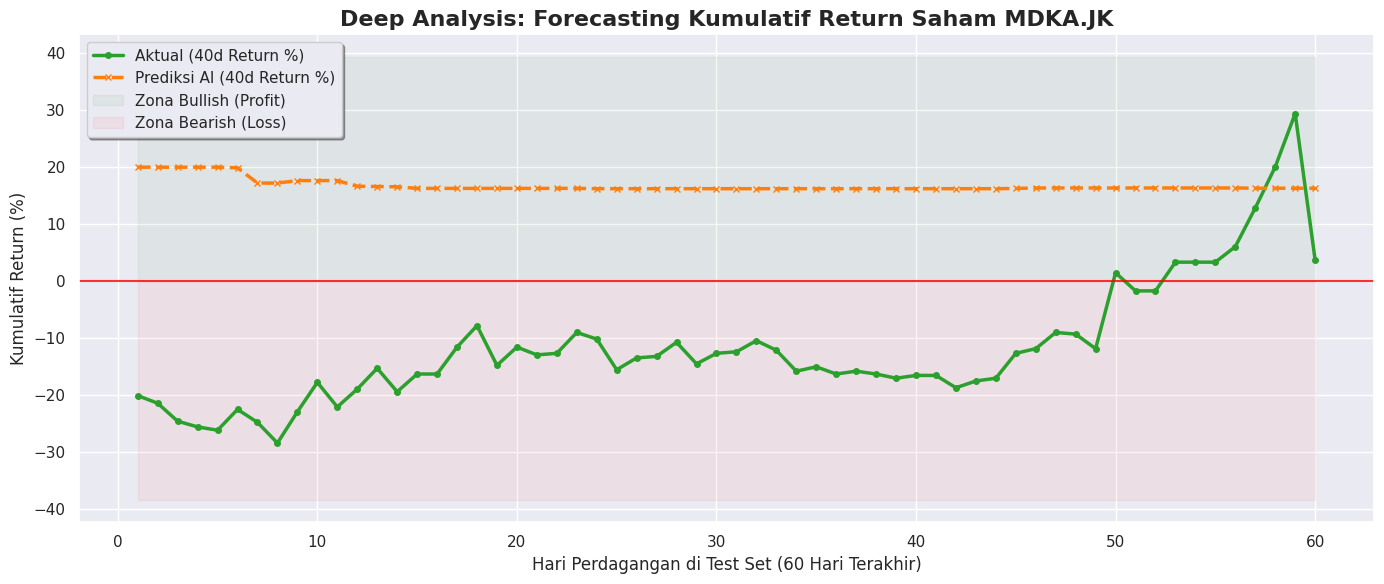


[*] Merender grafik analisis untuk HRTA.JK...


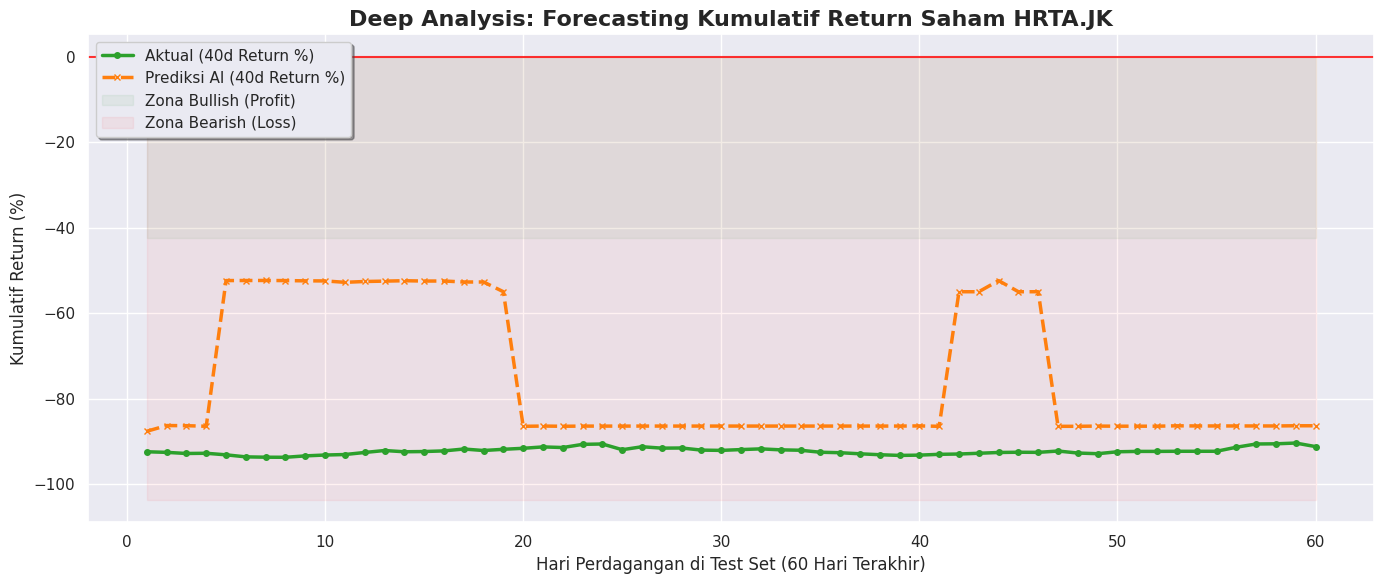


[*] Merender grafik analisis untuk PSAB.JK...


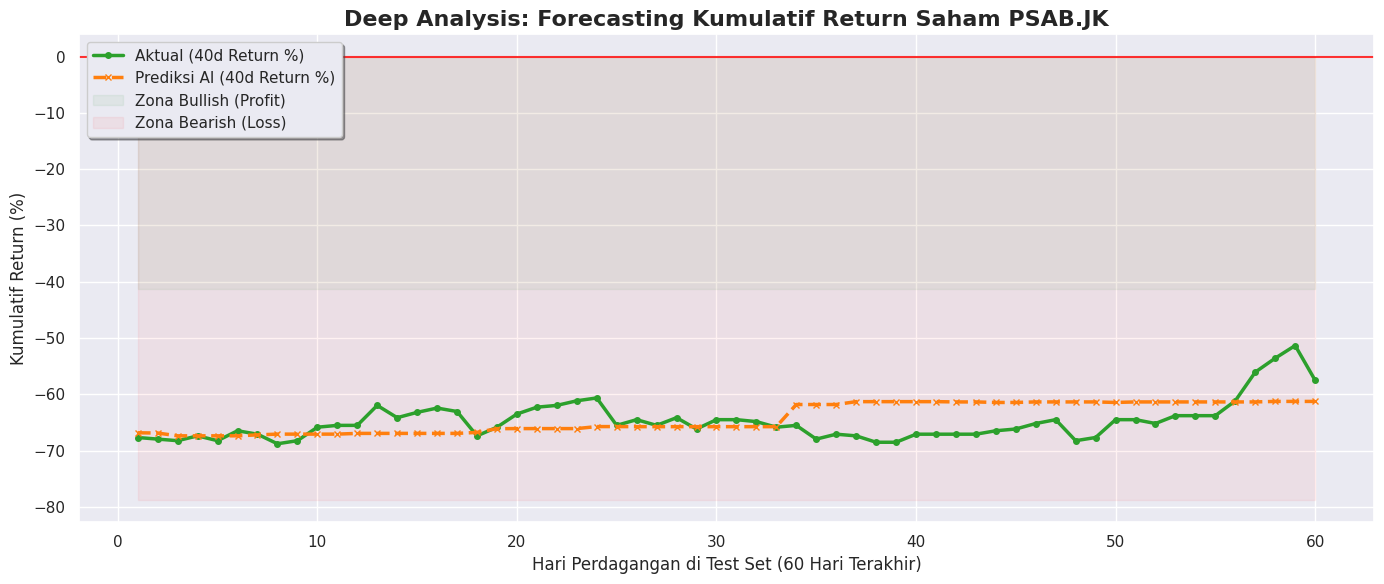

In [115]:
def visualisasi_postprocessing(ticker, y_actual, y_pred):
    """
    Fungsi buat nge-plot pergerakan Kumulatif Return aktual vs prediksi.
    Warna hijau buat area cuan (Bullish), merah buat area rugi (Bearish).
    """
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="darkgrid")
    
    # Konversi desimal ke persentase (%) biar gampang dianalisis
    y_actual_pct = y_actual * 100
    y_pred_pct = y_pred * 100
    
    # Bikin sumbu X berdasarkan panjang data test (60 hari)
    days = np.arange(1, len(y_actual) + 1)
    
    # Plotting Garis Utama
    plt.plot(days, y_actual_pct, label='Aktual (40d Return %)', color='#2ca02c', linewidth=2.5, marker='o', markersize=4)
    plt.plot(days, y_pred_pct, label='Prediksi AI (40d Return %)', color='#ff7f0e', linewidth=2.5, linestyle='--', marker='x', markersize=4)
    
    # Garis Nol (Batas Psikologis: Atas untung, bawah rugi)
    plt.axhline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
    
    # Bikin Shading Area biar presentasi lu kelihatan level pro
    y_max = max(max(y_actual_pct), max(y_pred_pct)) + 10
    y_min = min(min(y_actual_pct), min(y_pred_pct)) - 10
    plt.fill_between(days, 0, y_max, color='green', alpha=0.05, label='Zona Bullish (Profit)')
    plt.fill_between(days, y_min, 0, color='red', alpha=0.05, label='Zona Bearish (Loss)')
    
    # Kosmetik Chart
    plt.title(f'Deep Analysis: Forecasting Kumulatif Return Saham {ticker}', fontsize=16, fontweight='bold')
    plt.xlabel('Hari Perdagangan di Test Set (60 Hari Terakhir)', fontsize=12)
    plt.ylabel('Kumulatif Return (%)', fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()
    plt.savefig(f'forecast saham {ticker}.png')
    plt.show()

print("\n" + "="*50)
print("POST-PROCESSING & VISUALISASI")
print("="*50)

for ticker in daftar_saham:
    print(f"\n[*] Merender grafik analisis untuk {ticker}...")
    
    # Ambil kunci jawaban dan hasil tebakan dari lemari lu
    y_actual = lemari_split_dataset[ticker]['y_test']
    
    # Asumsi: lu udah nyelipin 'preds' ke lemari_evaluasi di Tahap 3
    # Kalo error KeyError: 'preds', cek lagi kodingan Tahap 3 lu cuy!
    y_pred = lemari_evaluasi[ticker]['preds'] 
    
    visualisasi_postprocessing(ticker, y_actual, y_pred)

---

# **TAHAP 4: The 5-Stock Loop (Pabrik Perakitan)**

Karena lu mau gabungin di 1 *notebook*, lu **nggak boleh** nge-*load* 5 model bebarengan di memori.

* Kita bikin *looping*: `for ticker in ['ANTM.JK', 'BRMS.JK', 'MDKA.JK', 'HRTA.JK', 'PSAB.JK']:`
* Di dalam *loop* ini, Tahap 1 sampai 3 dieksekusi secara bergantian.
* Setelah model untuk ANTM selesai di- *train*, evaluasinya di-*print*, terus modelnya langsung di-*save* ke *hardisk* (format `.h5` buat GRU dan `.json`/`.pkl` buat XGBoost).
* Setelah di-*save*, kita bersihin RAM lu pakai sintaks `del model` dan `gc.collect()`. Baru lanjut ke saham BRMS. Gitu terus sampai kelar. Ini cara paling elegan *coding* di mesin terbatas.

---

# **TAHAP 5: Evaluasi & Visualisasi (Rapot Kelulusan)**

Di akhir tiap *loop*, kita hitung seberapa jago model lu.

* **Directional Accuracy:** Ngecek seberapa sering arah tebakan model lu (Naik/Turun) sesuai sama realita. Target kita > 60%.
* **MAPE (Mean Absolute Percentage Error):** Ngecek seberapa meleset persentase *return* yang ditebak model. Target kita < 50%.
* **Plotting:** Kita *print* grafik *Actual vs Predicted* pakai Seaborn, lengkap sama warna zona merah (Bearish) dan hijau (Bullish) biar dosen lu bisa ngelihat performanya secara visual.